In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=5f7eb0643f3e0c2313a53f754f7a211e2513fb5ff745690135f64fbc9498c36b
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

In [ ]:
spark = SparkSession \
    .builder \
    .appName("Spark_NLP") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

**Tokenization**

In [ ]:
#create data frame

df2=spark.createDataFrame([(1,'I really liked this movie watching this movie was an unforgetable experience'),
                         (2,'I would recommend this movie to my friends and family'),
                         (3,'movie was alright but acting was horrible'),
                         (4,'I am never watching that movie ever again'),
                         (5,'This movie is boring but it has some good effects so not recommending')],
                        ['user_id','review'])
df2.show(5,False)
# When False is passed as the second argument, it means that long strings will not be truncated.

+-------+----------------------------------------------------------------------------+
|user_id|review                                                                      |
+-------+----------------------------------------------------------------------------+
|1      |I really liked this movie watching this movie was an unforgetable experience|
|2      |I would recommend this movie to my friends and family                       |
|3      |movie was alright but acting was horrible                                   |
|4      |I am never watching that movie ever again                                   |
|5      |This movie is boring but it has some good effects so not recommending       |
+-------+----------------------------------------------------------------------------+



In [ ]:
from pyspark.ml.feature import Tokenizer
tokenization=Tokenizer(inputCol='review',outputCol='tokens')
tokenized_df2=tokenization.transform(df2)
tokenized_df2.show(5,False)

+-------+----------------------------------------------------------------------------+-----------------------------------------------------------------------------------------+
|user_id|review                                                                      |tokens                                                                                   |
+-------+----------------------------------------------------------------------------+-----------------------------------------------------------------------------------------+
|1      |I really liked this movie watching this movie was an unforgetable experience|[i, really, liked, this, movie, watching, this, movie, was, an, unforgetable, experience]|
|2      |I would recommend this movie to my friends and family                       |[i, would, recommend, this, movie, to, my, friends, and, family]                         |
|3      |movie was alright but acting was horrible                                   |[movie, was, alright, but, ac

**Stopward Removal**

In [ ]:
from pyspark.ml.feature import StopWordsRemover
stopword_removal=StopWordsRemover(inputCol='tokens',outputCol='refined_tokens')
#We then pass the tokens as the input column and name the output column as refined tokens.
refined_df2=stopword_removal.transform(tokenized_df2)
refined_df2.select(['user_id','tokens','refined_tokens']).show(4,False)

+-------+-----------------------------------------------------------------------------------------+-----------------------------------------------------------------+
|user_id|tokens                                                                                   |refined_tokens                                                   |
+-------+-----------------------------------------------------------------------------------------+-----------------------------------------------------------------+
|1      |[i, really, liked, this, movie, watching, this, movie, was, an, unforgetable, experience]|[really, liked, movie, watching, movie, unforgetable, experience]|
|2      |[i, would, recommend, this, movie, to, my, friends, and, family]                         |[recommend, movie, friends, family]                              |
|3      |[movie, was, alright, but, acting, was, horrible]                                        |[movie, alright, acting, horrible]                               |
|4  

**Converting into numerical form/Feature Engineering**

**Count Vectorizer**

In [ ]:
from pyspark.ml.feature import CountVectorizer
count_vec=CountVectorizer(inputCol='refined_tokens',outputCol='tf-features')
cv_df2=count_vec.fit(refined_df2).transform(refined_df2)
cv_df2.select(['user_id','refined_tokens','tf-features']).show(5,False)

+-------+-----------------------------------------------------------------+---------------------------------------------+
|user_id|refined_tokens                                                   |tf-features                                  |
+-------+-----------------------------------------------------------------+---------------------------------------------+
|1      |[really, liked, movie, watching, movie, unforgetable, experience]|(18,[0,1,2,5,7,12],[2.0,1.0,1.0,1.0,1.0,1.0])|
|2      |[recommend, movie, friends, family]                              |(18,[0,4,10,11],[1.0,1.0,1.0,1.0])           |
|3      |[movie, alright, acting, horrible]                               |(18,[0,3,9,17],[1.0,1.0,1.0,1.0])            |
|4      |[never, watching, movie, ever]                                   |(18,[0,1,8,14],[1.0,1.0,1.0,1.0])            |
|5      |[movie, boring, good, effects, recommending]                     |(18,[0,6,13,15,16],[1.0,1.0,1.0,1.0,1.0])    |
+-------+---------------

In [ ]:
#To validate the vocabulary of the count vectorizer, we can simply use the vocabulary function:
vocabulary=count_vec.fit(refined_df2).vocabulary
vocabulary

['movie',
 'watching',
 'experience',
 'horrible',
 'recommend',
 'liked',
 'effects',
 'really',
 'never',
 'alright',
 'family',
 'friends',
 'unforgetable',
 'good',
 'ever',
 'boring',
 'recommending',
 'acting']

**TF-IDF**

Term Frequency: Score based on the frequency of the word in the current document

Inverse Document Frequency: Scoring based on the number of documents that contain the current word

In [ ]:
from pyspark.ml.feature import HashingTF,IDF
tf_idf_vec2=IDF(inputCol='tf-features',outputCol='tf_idf_features')
tf_idf_df2=tf_idf_vec2.fit(cv_df2).transform(cv_df2)
tf_idf_df2.select(['user_id', 'refined_tokens','tf_idf_features']).show(5,False)

+-------+-----------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+
|user_id|refined_tokens                                                   |tf_idf_features                                                                                                         |
+-------+-----------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+
|1      |[really, liked, movie, watching, movie, unforgetable, experience]|(18,[0,1,2,5,7,12],[0.0,0.6931471805599453,1.0986122886681098,1.0986122886681098,1.0986122886681098,1.0986122886681098])|
|2      |[recommend, movie, friends, family]                              |(18,[0,4,10,11],[0.0,1.0986122886681098,1.0986122886681098,1.0986122886681098])                                         |
|3      |[movie

**N-Gram Model**

In [ ]:
from pyspark.ml.feature import NGram

ngram = NGram(n=2, inputCol="refined_tokens", outputCol="ngrams")

NGram_df = ngram.transform(refined_df2)
NGram_df.select("refined_tokens","ngrams").show(truncate=False)


+-----------------------------------------------------------------+--------------------------------------------------------------------------------------------------------+
|refined_tokens                                                   |ngrams                                                                                                  |
+-----------------------------------------------------------------+--------------------------------------------------------------------------------------------------------+
|[really, liked, movie, watching, movie, unforgetable, experience]|[really liked, liked movie, movie watching, watching movie, movie unforgetable, unforgetable experience]|
|[recommend, movie, friends, family]                              |[recommend movie, movie friends, friends family]                                                        |
|[movie, alright, acting, horrible]                               |[movie alright, alright acting, acting horrible]                    

In [ ]:
NGram_df.show()

+-------+--------------------+--------------------+--------------------+--------------------+
|user_id|              review|              tokens|      refined_tokens|              ngrams|
+-------+--------------------+--------------------+--------------------+--------------------+
|      1|I really liked th...|[i, really, liked...|[really, liked, m...|[really liked, li...|
|      2|I would recommend...|[i, would, recomm...|[recommend, movie...|[recommend movie,...|
|      3|movie was alright...|[movie, was, alri...|[movie, alright, ...|[movie alright, a...|
|      4|I am never watchi...|[i, am, never, wa...|[never, watching,...|[never watching, ...|
|      5|This movie is bor...|[this, movie, is,...|[movie, boring, g...|[movie boring, bo...|
+-------+--------------------+--------------------+--------------------+--------------------+



In [ ]:
from pyspark.ml.feature import CountVectorizer
ngram_vec=CountVectorizer(inputCol='ngrams',outputCol='N-features')
ngram_df2=ngram_vec.fit(NGram_df).transform(NGram_df)
ngram_df2.select(['ngrams','N-features']).show(4,False)

+--------------------------------------------------------------------------------------------------------+----------------------------------------------+
|ngrams                                                                                                  |N-features                                    |
+--------------------------------------------------------------------------------------------------------+----------------------------------------------+
|[really liked, liked movie, movie watching, watching movie, movie unforgetable, unforgetable experience]|(18,[0,3,5,8,13,14],[1.0,1.0,1.0,1.0,1.0,1.0])|
|[recommend movie, movie friends, friends family]                                                        |(18,[6,7,17],[1.0,1.0,1.0])                   |
|[movie alright, alright acting, acting horrible]                                                        |(18,[2,15,16],[1.0,1.0,1.0])                  |
|[never watching, watching movie, movie ever]                               

In [ ]:
Ng_vocabulary=ngram_vec.fit(NGram_df).vocabulary
Ng_vocabulary

['watching movie',
 'effects recommending',
 'alright acting',
 'movie unforgetable',
 'movie boring',
 'unforgetable experience',
 'friends family',
 'recommend movie',
 'liked movie',
 'movie ever',
 'good effects',
 'boring good',
 'never watching',
 'really liked',
 'movie watching',
 'acting horrible',
 'movie alright',
 'movie friends']

**Word2Vec for feature representation**

In [ ]:
# Word2Vec model
from pyspark.ml.feature import Word2Vec
word2vec = Word2Vec(vectorSize=100, minCount=1, inputCol="refined_tokens", outputCol="W2Vfeatures")

#each word will be represented as a dense vector of 100 dimensions.
#minCount=5 denotes minimum frequency a word must have to be included in the Word2Vec model.
#Words that occur fewer than 5 times in the corpus will be ignored.
word2vec_model = word2vec.fit(refined_df2)
vectorized_data = word2vec_model.transform(refined_df2)
vectorized_data.select(['refined_tokens', 'W2Vfeatures']).show(truncate=False)

+-----------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
embeddings=word2vec_model.getVectors()
embeddings.printSchema()

root
 |-- word: string (nullable = true)
 |-- vector: vector (nullable = true)



In [ ]:
from pyspark.ml.functions import vector_to_array
embeddings=embeddings.withColumn('vector',vector_to_array('vector'))
embeddings.printSchema()

root
 |-- word: string (nullable = true)
 |-- vector: array (nullable = false)
 |    |-- element: double (containsNull = false)



In [ ]:
embeddings.show(30,False)

+------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
#use explainParams() to understand value of each parameter for your trained model
word2vec_model.explainParams()

"inputCol: input column name. (current: refined_tokens)\nmaxIter: max number of iterations (>= 0). (default: 1)\nmaxSentenceLength: Maximum length (in words) of each sentence in the input data. Any sentence longer than this threshold will be divided into chunks up to the size. (default: 1000)\nminCount: the minimum number of times a token must appear to be included in the word2vec model's vocabulary (default: 5, current: 1)\nnumPartitions: number of partitions for sentences of words (default: 1)\noutputCol: output column name. (default: Word2Vec_b02801dded6d__output, current: W2Vfeatures)\nseed: random seed. (default: -1638475637177511688)\nstepSize: Step size to be used for each iteration of optimization (>= 0). (default: 0.025)\nvectorSize: the dimension of codes after transforming from words (default: 100, current: 100)\nwindowSize: the window size (context words from [-window, window]). Default value is 5 (default: 5)"

In [ ]:
word2vec_model.getWindowSize()

5

In [ ]:
word2vec_model.getVectorSize()

100

In [ ]:
word2vec_model.getMinCount()

1

In [ ]:
pd_df_embedding = embeddings.toPandas()
pd_df_embedding.head()

,word,vector
0,recommend,"[-0.0006958532612770796, 0.0012744575506076217..."
1,horrible,"[-0.0008504724828526378, -0.000866301124915480..."
2,effects,"[-0.002970385132357478, 0.00282745948061347, -..."
3,watching,"[0.0013720489805564284, -0.00449774693697691, ..."
4,good,"[0.0014033564366400242, -0.0007299472927115858..."


In [ ]:
import pandas as pd
X=pd.DataFrame(pd_df_embedding['vector'].values.tolist())
X.shape

(18, 100)

In [ ]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.000696,0.001274,-0.004553,0.000052,-0.004847,-0.000154,0.003960,0.003730,0.002292,-0.001316,...,-0.003519,-0.003763,0.004118,-0.001807,-0.003888,-0.001048,-0.004705,-0.000569,0.001514,-0.002761
1,-0.000850,-0.000866,-0.001152,-0.000922,0.000586,-0.001391,-0.000455,0.002072,0.002043,-0.004593,...,0.002899,-0.002141,0.000870,0.000894,-0.001397,0.004161,0.003677,0.000698,0.002256,-0.000840
2,-0.002970,0.002827,-0.004772,-0.002978,0.001015,-0.001984,0.004801,0.000743,-0.004249,0.002805,...,-0.004395,-0.001509,0.003726,-0.001212,0.004668,-0.004485,-0.001356,-0.003729,-0.002754,-0.003263
3,0.001372,-0.004498,-0.004957,0.002666,-0.000110,-0.004660,0.003241,0.004405,-0.000365,-0.001983,...,0.003281,-0.001160,-0.002483,-0.002667,0.001434,0.004774,0.004489,0.000988,-0.002721,0.001273
4,0.001403,-0.000730,-0.002190,0.001149,0.002646,0.003732,0.004088,-0.000897,-0.001620,0.003011,...,-0.003877,-0.001169,0.000764,0.004221,0.001565,0.000948,-0.001499,-0.001944,-0.003600,0.000710


In [ ]:
word_categories=embeddings.select('word').distinct().collect()
unique_words = [i.word for i in word_categories]
print(unique_words)

['horrible', 'boring', 'watching', 'movie', 'experience', 'good', 'effects', 'recommend', 'unforgetable', 'friends', 'liked', 'acting', 'family', 'really', 'recommending', 'never', 'alright', 'ever']


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_df = pca.fit_transform(X)
pca_df

array([[ 1.30007027e-02,  1.02319764e-02],
       [-7.60314105e-03, -5.20848442e-03],
       [ 6.92576282e-03, -1.29162496e-03],
       [-8.32586831e-04, -9.46925606e-03],
       [-1.04302112e-02, -1.10986869e-02],
       [-5.93766169e-03,  1.31405173e-02],
       [ 2.23692448e-02, -5.83241117e-03],
       [-2.37295025e-03,  1.54854511e-02],
       [ 6.31807810e-03,  8.79419258e-03],
       [-1.45407233e-03,  7.54326351e-03],
       [ 9.24782637e-03, -5.04944698e-03],
       [-1.01506946e-02, -3.14733973e-03],
       [-6.92227429e-03, -4.39804312e-03],
       [-1.04443289e-02,  1.05511335e-02],
       [ 8.59554017e-05, -8.96592101e-03],
       [ 5.78481593e-03, -9.08452960e-04],
       [-5.67880318e-03,  1.57061376e-03],
       [-1.90566177e-03, -1.19474808e-02]])

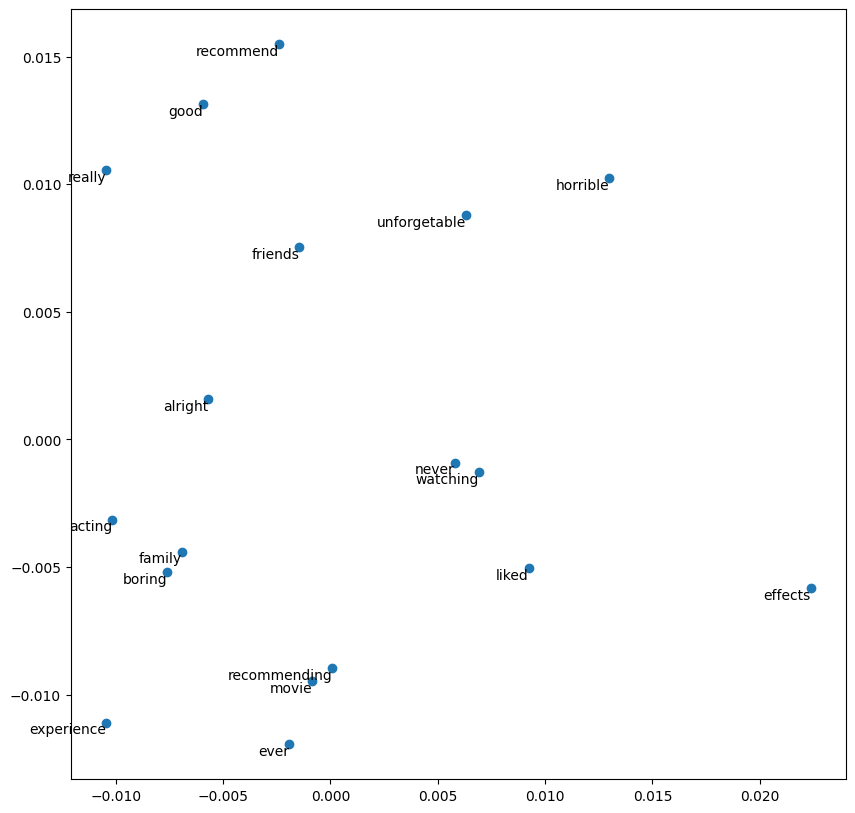

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
plt.scatter(pca_df[:, 0], pca_df[:, 1])
for i,unique_words in enumerate(unique_words):
  plt.annotate(unique_words,horizontalalignment='right',verticalalignment='top',xy=(pca_df[i, 0], pca_df[i, 1]))
plt.show()